<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [1]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

### Datos
Utilizaremos como dataset canciones de bandas de habla inglés.

In [ ]:
# descargar de textos.info
import requests
import certifi

# Para leer y parsear el texto en HTML
import bs4 as bs

In [24]:
url = 'https://www.textos.info/julio-verne/la-vuelta-al-mundo-en-80-dias/ebook'
response = requests.get(url, timeout=30, verify=certifi.where())
response.raise_for_status()
raw_html = response.content

# Parsear artículo: usar lxml si está disponible, sino fallback a parser estándar
try:
    article_html = bs.BeautifulSoup(raw_html, 'lxml')
except Exception:
    article_html = bs.BeautifulSoup(raw_html, 'html.parser')

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '

# pasar todo el texto a minúscula
article_text = article_text.lower()

In [25]:
# en article text se encuentra el texto de todo el libro
article_text[:1000]

' en el año 1872, la casa número 7 de saville-row, burlington gardens \r\n—donde murió sheridan en 1814— estaba habitada por phileas fogg, quien a\r\n pesar de que parecía haber tomado el partido de no hacer nada que \r\npudiese llamar la atención, era uno de los miembros más notables y \r\nsingulares del reformclub de londres. por consiguiente, phileas fogg, personaje enigmático y del cual sólo \r\nse sabía que era un hombre muy galante y de los más cumplidos gentlemen \r\nde la alta sociedad inglesa, sucedía a uno de los más grandes oradores \r\nque honran a inglaterra. decíase que se daba un aire a lo byron —su cabeza, se entiende, \r\nporque, en cuanto a los pies, no tenía defecto alguno—, pero a un byron \r\nde bigote y pastillas, a un byron impasible, que hubiera vivido mil años\r\n sin envejecer. phileas fogg, era inglés de pura cepa; pero quizás no había nacido en\r\n londres. jamás se le había visto en la bolsa ni en el banco, ni en \r\nninguno de los despachos mercantiles de 

### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [5]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [6]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [7]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)

In [8]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

68

In [9]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar

In [10]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [11]:
tokenized_text[:1000]

[57,
 53,
 15,
 57,
 53,
 2,
 57,
 55,
 1,
 33,
 57,
 34,
 20,
 37,
 22,
 42,
 57,
 2,
 55,
 57,
 23,
 55,
 47,
 55,
 57,
 15,
 41,
 3,
 53,
 35,
 33,
 57,
 37,
 57,
 8,
 53,
 57,
 47,
 55,
 54,
 29,
 2,
 2,
 53,
 12,
 35,
 33,
 5,
 42,
 57,
 14,
 64,
 35,
 2,
 29,
 15,
 38,
 13,
 33,
 15,
 57,
 38,
 55,
 35,
 8,
 53,
 15,
 47,
 57,
 56,
 50,
 31,
 8,
 33,
 15,
 8,
 53,
 57,
 3,
 64,
 35,
 29,
 39,
 57,
 47,
 21,
 53,
 35,
 29,
 8,
 55,
 15,
 57,
 53,
 15,
 57,
 34,
 20,
 34,
 17,
 31,
 57,
 53,
 47,
 13,
 55,
 14,
 55,
 57,
 21,
 55,
 14,
 29,
 13,
 55,
 8,
 55,
 57,
 9,
 33,
 35,
 57,
 9,
 21,
 29,
 2,
 53,
 55,
 47,
 57,
 7,
 33,
 38,
 38,
 42,
 57,
 58,
 64,
 29,
 53,
 15,
 57,
 55,
 56,
 50,
 57,
 9,
 53,
 47,
 55,
 35,
 57,
 8,
 53,
 57,
 58,
 64,
 53,
 57,
 9,
 55,
 35,
 53,
 23,
 67,
 55,
 57,
 21,
 55,
 14,
 53,
 35,
 57,
 13,
 33,
 3,
 55,
 8,
 33,
 57,
 53,
 2,
 57,
 9,
 55,
 35,
 13,
 29,
 8,
 33,
 57,
 8,
 53,
 57,
 15,
 33,
 57,
 21,
 55,
 23,
 53,
 35,
 57,
 15,
 55,
 8,

### Organizando y estructurando el dataset

In [12]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [13]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [14]:
tokenized_sentences_val = [val_text[init*max_context_size:(init+1)*max_context_size] for init in range(num_val)]

In [15]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [16]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

En este punto tenemos en la variable `tokenized_sentences` los versos tokenizados. Vamos a quedarnos con un conjunto de validación que utilizaremos para medir la calidad de la generación de secuencias con la métrica de Perplejidad.

In [17]:
X.shape

(359671, 100)

In [18]:
X[0,:10]

array([57, 53, 15, 57, 53,  2, 57, 55,  1, 33])

In [19]:
y[0,:10]

array([53, 15, 57, 53,  2, 57, 55,  1, 33, 57])

In [20]:
vocab_size = len(chars_vocab)

# Definiendo el modelo

In [ ]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

El modelo que se propone como ejemplo consume los índices de los tokens y los transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` que transforma a índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.

In [ ]:
model = Sequential()

model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model.summary()


### Definir el modelo

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [ ]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl,patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save("my_model.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True


### Entrenamiento

In [ ]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
history_ppl = []
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl)], batch_size=256)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
plt.show()

In [ ]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
import os

model_path = 'my_model.keras'
if not os.path.exists(model_path):
    raise FileNotFoundError(f'No se encontró {model_path}. Ejecutá primero la celda de entrenamiento.')

model = keras.models.load_model(model_path, compile=False)
print(f'Modelo cargado: {model_path}')


### Predicción del próximo caracter

In [ ]:
# Se puede usar gradio para probar el modelo
# Gradio es una herramienta muy útil para crear interfaces para ensayar modelos
# https://gradio.app/

%pip install -q gradio

In [ ]:
import gradio as gr

def model_response(human_text):

    # Encodeamos
    encoded = [char2idx[ch] for ch in human_text.lower() ]
    # Si tienen distinto largo
    encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

    # Predicción softmax
    y_hat = np.argmax(model.predict(encoded)[0,-1,:])


    # Debemos buscar en el vocabulario el caracter
    # que corresopnde al indice (y_hat) predicho por le modelo
    out_word = ''
    out_word = idx2char[y_hat]

    # Agrego la palabra a la frase predicha
    return human_text + out_word

iface = gr.Interface(
    fn=model_response,
    inputs=["textbox"],
    outputs="text")

iface.launch(debug=True)

### Generación de secuencias

In [ ]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [ ]:
input_text='habia una vez'

generate_seq(model, input_text, max_length=max_context_size, n_words=30)

###  Beam search y muestreo aleatorio

In [ ]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [ ]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [ ]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=20,input="habia una vez")

In [ ]:
salidas[0]

In [ ]:
# veamos las salidas
decode(salidas[0])

# Desarrollo

### Selección de corpus

Para el desarrollo de este trabajo, se utilizará la obra literaria "El gaucho Martín Fierro" de José Hernández.

In [10]:
# descargar de textos.info
import requests
import certifi

# Para leer y parsear el texto en HTML
import bs4 as bs

In [11]:
url = 'https://www.textos.info/jose-hernandez/el-gaucho-martin-fierro/ebook'
response = requests.get(url, timeout=30, verify=certifi.where())
response.raise_for_status()
raw_html = response.content

# Parsear artículo: usar lxml si está disponible, sino fallback a parser estándar
try:
    article_html = bs.BeautifulSoup(raw_html, 'lxml')
except Exception:
    article_html = bs.BeautifulSoup(raw_html, 'html.parser')

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

text = ''

for para in article_paragraphs:
    text += para.text + ' '

# pasar todo el texto a minúscula
text = text.lower()

In [12]:
text[:1000]

' aquí me pongo a cantar\r\nal compás de la vigüela,\r\nque el hombre que lo desvela\r\nuna pena estrordinaria,\r\ncomo la ave solitaria\r\ncon el cantar se consuela. pido a los santos del cielo\r\nque ayuden mi pensamiento,\r\nles pido en este momento\r\nque voy a cantar mi historia\r\nme refresquen la memoria\r\ny aclaren mi entendimiento. vengan santos milagrosos,\r\nvengan todos en mi ayuda,\r\nque la lengua se me añuda\r\ny se me turba la vista;\r\npido a mi dios que me asista\r\nen una ocasión tan ruda. yo he visto muchos cantores,\r\ncon famas bien otenidas,\r\ny que después de alquiridas\r\nno las quieren sustentar-\r\nparece que sin largar\r\nse cansaron en partidas. mas ande otro criollo pasa\r\nmartín fierro ha de pasar,\r\nnada lo hace recular\r\nni las fantasmas lo espantan;\r\ny dende que todos cantan\r\nyo también quiero cantar. cantando me he de morir,\r\ncantando me han de enterrar,\r\ny cantando he de llegar\r\nal pie del eterno padre-\r\ndende el vientre de mi madre\

### Preprocesamiento

In [13]:
import re

text = text.lower() # convertir a minúsculas
text = re.sub(r"\n+", " eol ", text) # identificar saltos de línea para poder tokenizarlos
text = re.sub(r"[ \t]+", " ", text) # reemplazar múltiples espacios por uno solo
text = text.strip() # eliminar espacios en blanco al inicio y al final


In [14]:
text[:1000]

'aquí me pongo a cantar\r eol al compás de la vigüela,\r eol que el hombre que lo desvela\r eol una pena estrordinaria,\r eol como la ave solitaria\r eol con el cantar se consuela. pido a los santos del cielo\r eol que ayuden mi pensamiento,\r eol les pido en este momento\r eol que voy a cantar mi historia\r eol me refresquen la memoria\r eol y aclaren mi entendimiento. vengan santos milagrosos,\r eol vengan todos en mi ayuda,\r eol que la lengua se me añuda\r eol y se me turba la vista;\r eol pido a mi dios que me asista\r eol en una ocasión tan ruda. yo he visto muchos cantores,\r eol con famas bien otenidas,\r eol y que después de alquiridas\r eol no las quieren sustentar-\r eol parece que sin largar\r eol se cansaron en partidas. mas ande otro criollo pasa\r eol martín fierro ha de pasar,\r eol nada lo hace recular\r eol ni las fantasmas lo espantan;\r eol y dende que todos cantan\r eol yo también quiero cantar. cantando me he de morir,\r eol cantando me han de enterrar,\r eol y ca

Debido a que el Martín Fierro es un poema narrativo, se identifican los saltos de línea para poder tokenizarlos y que el modelo pueda aprender la estructura de frase/verso.

### Tokenización

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\r')
tokenizer.fit_on_texts([text])

Para la tokenización, se eliminan los caracteres especiales, incluidos los de puntuación.

In [16]:
word2idx = tokenizer.word_index
idx2word = {i: w for w, i in word2idx.items()}

vocab_size = len(word2idx) + 1  # el indice 0 se reserva para padding

print("Tamaño del vocabulario:", vocab_size)
print(list(word2idx.items())[:20])

Tamaño del vocabulario: 3009
[('eol', 1), ('y', 2), ('que', 3), ('el', 4), ('la', 5), ('de', 6), ('a', 7), ('en', 8), ('me', 9), ('no', 10), ('un', 11), ('se', 12), ('lo', 13), ('los', 14), ('al', 15), ('las', 16), ('con', 17), ('le', 18), ('como', 19), ('yo', 20)]


In [17]:
# Convertir texto a lista de numeros
sequence = tokenizer.texts_to_sequences([text])[0]

In [18]:
print("Cantidad total de tokens:", len(sequence))
print(sequence[:30])

Cantidad total de tokens: 13382
[133, 9, 583, 7, 91, 1, 15, 1020, 6, 5, 1021, 1, 3, 4, 46, 3, 13, 1022, 1, 21, 584, 1023, 1, 19, 5, 585, 1024, 1, 17, 4]


### Construcción del dataset

In [19]:
max_len = 20

X = []
y = []

for i in range(max_len, len(sequence)):
    X.append(sequence[i - max_len:i])
    y.append(sequence[i])

In [20]:
X = np.array(X)
y = np.array(y)

In [21]:
print(X.shape)
print(y.shape)

(13362, 20)
(13362,)


In [22]:
print(sequence[:30])
print(X[0])
print(y[0])

[133, 9, 583, 7, 91, 1, 15, 1020, 6, 5, 1021, 1, 3, 4, 46, 3, 13, 1022, 1, 21, 584, 1023, 1, 19, 5, 585, 1024, 1, 17, 4]
[ 133    9  583    7   91    1   15 1020    6    5 1021    1    3    4
   46    3   13 1022    1   21]
584


A partir de la secuencia de tokens se generó un conjunto de entrenamiento mediante una ventana deslizante de longitud fija (tamaño ventana/max_len). Cada muestra de entrada consiste en una secuencia de palabras de contexto, mientras que la salida corresponde a la palabra siguiente en el texto.

### División del dataset

Se dedica el 80% para entrenamiento, el resto para evaluación.

In [23]:
split_idx = int(0.8 * len(X))

X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

In [24]:
print("Tamaño del train:",X_train.shape)
print("Tamaño del train target:",y_train.shape)
print("Tamaño del validation:",X_val.shape)
print("Tamaño del validation target:",y_val.shape)

Tamaño del train: (10689, 20)
Tamaño del train target: (10689,)
Tamaño del validation: (2673, 20)
Tamaño del validation target: (2673,)


### Modelo

Para el desarrollo de los modelos, se proponen tres arquitecturas:
- Modelo simple con SimpleRNN
- Modelo basado en GRU
- Modelo basado en LSTM

En cada modelo se utiliza una capa de embeddings para representar las palabras. La dimensión es de 128, ya que no se cuenta con un dataset muy grande y se lo considera como un punto de partida para capturar las relaciones semánticas entre las palabras pero sin sobredimensionar.

Se utilizaron 128 unidades recurrentes (simple RNN, GRU y LSTM) para que el modelo tenga capacidad suficiente para capturar relaciones sin incrementar excesivamente la cantidad de parámetros. Se utiliza la misma cantidad de unidades para todas las arquitecturas de manera que se pueda realizar una comparación entre ellas.

Se utiliza dropout de 0.1 para regularización.

Por último, se utiliza una capa densa con la función de activación softmax del tamaño igual al vocabulario.

In [25]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
#from keras.optimizers import RMSprop

**Modelo con SimpleRNN**

In [26]:
modelo_simple_rnn = Sequential()

modelo_simple_rnn.add(Input(shape=(max_len,))) # Permite calcular cantidad de parametros y tamaño del modelo
modelo_simple_rnn.add(Embedding(input_dim = vocab_size, output_dim = 128))
modelo_simple_rnn.add(SimpleRNN(units = 128, dropout = 0.1))
modelo_simple_rnn.add(Dense(vocab_size, activation = 'softmax'))
modelo_simple_rnn.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

modelo_simple_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 128)        │       385,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3009)           │       388,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 806,209 (3.08 MB)

 Trainable params: 806,209 (3.08 MB)

 Non-trainable params: 0 (0.00 B)

**Modelo GRU**

In [27]:
modelo_gru = Sequential()

modelo_gru.add(Input(shape=(max_len,))) # Permite calcular cantidad de parametros y tamaño del modelo
modelo_gru.add(Embedding(input_dim = vocab_size, output_dim = 128))
modelo_gru.add(GRU(128, dropout = 0.1))
modelo_gru.add(Dense(vocab_size, activation = 'softmax'))
modelo_gru.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

modelo_gru.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 20, 128)        │       385,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3009)           │       388,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,385 (3.33 MB)

 Trainable params: 872,385 (3.33 MB)

 Non-trainable params: 0 (0.00 B)

**Modelo LSTM**

In [28]:
modelo_lstm = Sequential()

modelo_lstm.add(Input(shape=(max_len,)))
modelo_lstm.add(Embedding(input_dim = vocab_size, output_dim = 128))
modelo_lstm.add(LSTM(128, dropout = 0.1))
modelo_lstm.add(Dense(vocab_size, activation = 'softmax'))
modelo_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

modelo_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 20, 128)        │       385,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3009)           │       388,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 904,897 (3.45 MB)

 Trainable params: 904,897 (3.45 MB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

In [154]:
import tensorflow as tf

print("GPU disponible:", tf.config.list_physical_devices('GPU'))

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [155]:
import tensorflow as tf

print("Versión TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))
print("CPUs:", tf.config.list_physical_devices('CPU'))

Versión TensorFlow: 2.16.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [156]:
class PplNextWordCallback(keras.callbacks.Callback):
    def __init__(self, X_val, y_val, history_ppl, patience=5, model_path="mejor_ppl_modelo.keras"):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.history_ppl = history_ppl
        self.patience = patience
        self.model_path = model_path
        self.min_score = np.inf
        self.patience_counter = 0

    def on_epoch_end(self, epoch, logs=None):
        predictions = self.model.predict(self.X_val, verbose=0)

        probs = predictions[np.arange(len(self.y_val)), self.y_val]
        probs = np.clip(probs, 1e-10, 1.0)

        current_score = np.exp(-np.mean(np.log(probs)))
        self.history_ppl.append(current_score)

        print(f"\nPerplejidad media: {current_score:.4f}\n")

        if current_score < self.min_score:
            self.min_score = current_score
            self.model.save(self.model_path)
            print("Nuevo modelo guardado")
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter >= self.patience:
                print("Entrenamiento detenido por Early Stopping")
                self.model.stop_training = True

**Modelo Simple RNN**

In [157]:
history_ppl = []

ppl_callback = PplNextWordCallback(
    X_val=X_val,
    y_val=y_val,
    history_ppl=history_ppl,
    patience=5,
    model_path="mejor_simple_rnn_ppl.keras"
)

history_simple_rnn = modelo_simple_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[ppl_callback])

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - loss: 6.7460
Perplejidad media: 396.3900

Nuevo modelo guardado
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 224ms/step - loss: 6.7404 - val_loss: 5.9824
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - loss: 5.9226
Perplejidad media: 380.0605

Nuevo modelo guardado
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 218ms/step - loss: 5.9242 - val_loss: 5.9403
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - loss: 5.7735
Perplejidad media: 313.7773

Nuevo modelo guardado
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 221ms/step - loss: 5.7730 - val_loss: 5.7487
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - loss: 5.5503
Perplejidad media: 288.6841

Nuevo modelo guardado
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 220ms/step - loss: 5.5507 - val_loss: 5.6653
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 5.4000
Perplejidad media: 275.4655

Nuevo modelo guardado
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 217ms/step - loss: 5.4001 - val_loss: 5.6185
Epoch 6/50
84/84 ━━━━━━━━━━━━━

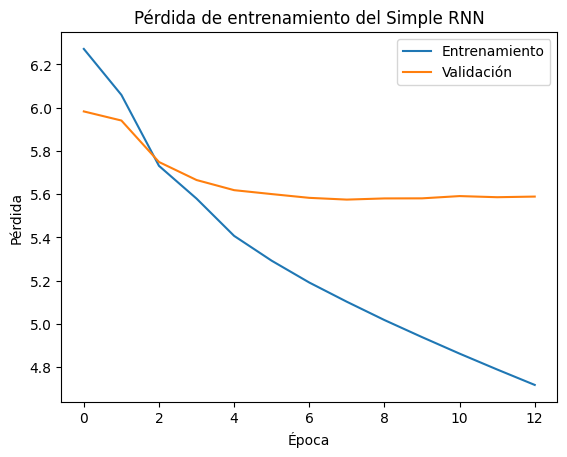

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_simple_rnn.history['loss'])
plt.plot(history_simple_rnn.history['val_loss'])

plt.title('Pérdida de entrenamiento del modelo Simple RNN')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend(['Entrenamiento', 'Validación'])
plt.show()

**Modelo GRU**

In [158]:
history_ppl = []

ppl_callback = PplNextWordCallback(
    X_val=X_val,
    y_val=y_val,
    history_ppl=history_ppl,
    patience=5,
    model_path="mejor_gru_ppl.keras"
)

history_gru = modelo_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[ppl_callback])

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.2126
Perplejidad media: 402.3885

Nuevo modelo guardado
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 7.2047 - val_loss: 5.9974
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.9050
Perplejidad media: 372.4149

Nuevo modelo guardado
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.9051 - val_loss: 5.9200
Epoch 3/50
81/84 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.7330
Perplejidad media: 335.5627

Nuevo modelo guardado
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.7343 - val_loss: 5.8158
Epoch 4/50
80/84 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 5.6263
Perplejidad media: 298.8737

Nuevo modelo guardado
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.6253 - val_loss: 5.7000
Epoch 5/50
81/84 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.4036
Perplejidad media: 287.2371

Nuevo modelo guardado
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.4061 - val_loss: 5.6603
Epoch 6/50
83/84 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms

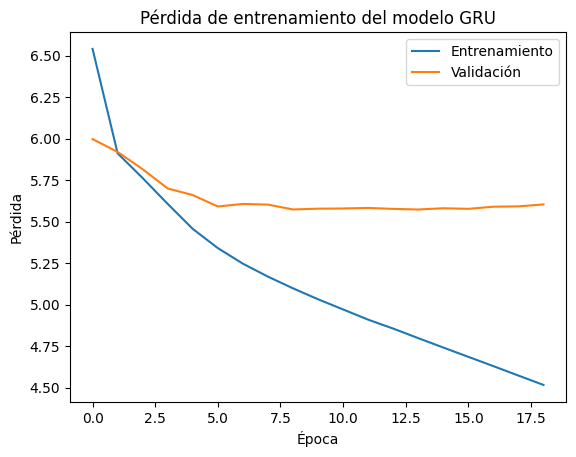

In [168]:
plt.plot(history_gru.history['loss'])
plt.plot(history_gru.history['val_loss'])

plt.title('Pérdida de entrenamiento del modelo GRU')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend(['Entrenamiento', 'Validación'])
plt.show()

**Modelo LSTM**

In [159]:
history_ppl = []

ppl_callback = PplNextWordCallback(
    X_val=X_val,
    y_val=y_val,
    history_ppl=history_ppl,
    patience=5,
    model_path="mejor_lstm_ppl.keras"
)

history_lstm = modelo_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[ppl_callback])

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.0506
Perplejidad media: 403.0606

Nuevo modelo guardado
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 7.0432 - val_loss: 5.9991
Epoch 2/50
82/84 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.9192
Perplejidad media: 398.8852

Nuevo modelo guardado
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.9196 - val_loss: 5.9887
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.8742
Perplejidad media: 389.9030

Nuevo modelo guardado
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 5.8745 - val_loss: 5.9659
Epoch 4/50
83/84 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.8273
Perplejidad media: 351.2817

Nuevo modelo guardado
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 5.8273 - val_loss: 5.8616
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.7188
Perplejidad media: 326.8651

Nuevo modelo guardado
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.7185 - val_loss: 5.7895
Epoch 6/50
80/84 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms

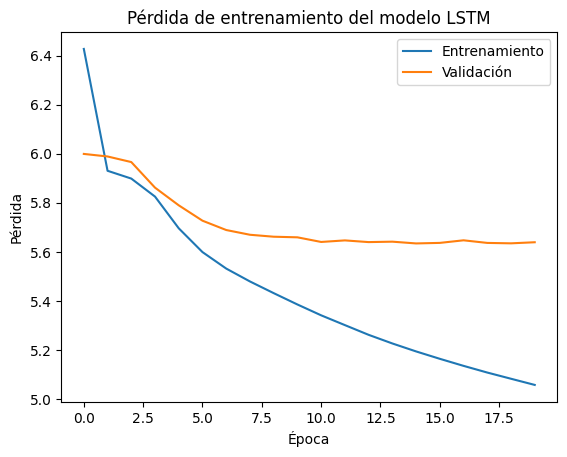

In [169]:
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])

plt.title('Pérdida de entrenamiento del modelo LSTM')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend(['Entrenamiento', 'Validación'])
plt.show()

Los resultados de entrenamiento mostraron que, en principio, SimpleRNN y GRU alcanzaron desempeños muy similares, con valores mínimos de perplejidad cercanos a 265 y pérdidas de validación prácticamente iguales. En cambio, LSTM obtuvo una perplejidad mayor y misma pérdida de validación.

En todos los modelos, se observa que la pérdida de validación se estabiliza a partir del la época 5 mientras que la pérdida de entrenamiento sigue bajando, por lo que a partir de esta época comienza a haber overfitting.

### Generación de secuencias con frases reales del corpus

Para la generación de secuencias se utilizaron fragmentos del corpus delimitados por tokens de fin de línea (eol), para asegurar que las semillas utilizadas correspondan a frases coherentes.

In [75]:
import random

def frases_reales(sequence, idx2word, word2idx, n_seeds=10, min_len=5, max_len=8):
    eol_idx = word2idx["eol"]

    seeds = []
    N = len(sequence)

    # Encontrar posiciones de eol
    eol_positions = [i for i, tok in enumerate(sequence) if tok == eol_idx]

    # Recorrer pares consecutivos de eol
    valid_segments = []
    for i in range(len(eol_positions) - 1):
        start = eol_positions[i] + 1
        end = eol_positions[i + 1]

        if end - start >= min_len:
            valid_segments.append((start, end))

    # Generar frases (seeds)
    for _ in range(n_seeds):
        seg_start, seg_end = random.choice(valid_segments)

        seg_len = seg_end - seg_start
        seed_len = random.randint(min_len, min(max_len, seg_len))

        start = random.randint(seg_start, seg_end - seed_len)
        window = sequence[start:start + seed_len]

        words = [idx2word[idx] for idx in window if idx != 0]

        seeds.append(" ".join(words))

    return seeds

In [76]:
frases_reales = frases_reales(
    sequence=sequence,
    idx2word=idx2word,
    word2idx=word2idx,
    n_seeds=10
)

for frase in frases_reales:
    print(frase)

un gaucho que pegó el grito
pero ha querido el destino
que el indio lo arregla todo
tiempo o en tal otro
lo pisé en las paletas
como yo en una ocasión
sin vasilar cuando el hombre está en peligro
mas lo mesmo que el carancho
lo dan vuelta panza arriba
y ansina me vide pronto


#### Greedy search

In [77]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Greedy search
def generate_seq_greedy(model, text, tokenizer, idx2word, max_length, n_words):

    output_text = text.lower()
    generated_words = output_text.split()

    for _ in range(n_words):
        # Codificar texto actual
        encoded = tokenizer.texts_to_sequences([' '.join(generated_words)])[0]
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

        # Predecir próxima palabra
        pred_probs = model.predict(encoded, verbose=0)[0]
        next_idx = np.argmax(pred_probs)

        # Convertir indice a palabra
        next_word = idx2word.get(next_idx, "")

        if next_word == "":
            break

        generated_words.append(next_word)

    return ' '.join(generated_words)

In [78]:
import tensorflow as tf
from tensorflow import keras

modelo_simple_rnn = keras.models.load_model("mejor_simple_rnn_ppl.keras")
modelo_gru = keras.models.load_model("mejor_gru_ppl.keras")
modelo_lstm = keras.models.load_model("mejor_lstm_ppl.keras")

modelos = [modelo_simple_rnn, modelo_gru, modelo_lstm]
nombres = ["Simple RNN", "GRU", "LSTM"]

In [80]:
for frase in frases_reales:

    print(f"Frase de entrada: '{frase}'")
    
    for i, modelo in enumerate(modelos):
        texto_generado = generate_seq_greedy(
            model=modelo,
            text=frase,
            tokenizer=tokenizer,
            idx2word=idx2word,
            max_length=max_len,
            n_words=10
        )
        print(f"Generación de texto {nombres[i]}: '{texto_generado}'")
    print("\n")

Frase de entrada: 'un gaucho que pegó el grito'
Generación de texto Simple RNN: 'un gaucho que pegó el grito eol y que que que el gente eol y que'
Generación de texto GRU: 'un gaucho que pegó el grito eol y me gaucho que el gaucho eol y me'
Generación de texto LSTM: 'un gaucho que pegó el grito eol y que que la gaucho eol y que que'


Frase de entrada: 'pero ha querido el destino'
Generación de texto Simple RNN: 'pero ha querido el destino eol y que que que el gente eol y que'
Generación de texto GRU: 'pero ha querido el destino eol y me gaucho que el gaucho eol y me'
Generación de texto LSTM: 'pero ha querido el destino eol y que que la gaucho eol y que que'


Frase de entrada: 'que el indio lo arregla todo'
Generación de texto Simple RNN: 'que el indio lo arregla todo eol y que que que el gente eol y que'
Generación de texto GRU: 'que el indio lo arregla todo eol que me gaucho que el gaucho eol y me'
Generación de texto LSTM: 'que el indio lo arregla todo eol y que que la gaucho eol 

La generación de texto mediante greedy search permitió verificar que los modelos recurrentes aprendieron parcialmente la estructura del corpus, especialmente el uso del token de fin de verso (eol) y ciertas palabras frecuentes.

Sin embargo, las secuencias generadas indican una tendencia a la repetición y una baja diversidad, ya que distintas frases iniciales llevan a continuaciones muy similares. Este comportamiento se debe principalmente a greedy search, que en cada paso selecciona la palabra más probable, lo que reduce la variabilidad. 

Entre los modelos evaluados, la arquitectura GRU presentó la generación relativamente más variada, mientras que SimpleRNN y LSTM tendieron a colapsar más rápidamente hacia patrones repetitivos.

#### Bearm search

In [81]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def beam_search(
    model,
    tokenizer,
    idx2word,
    text,
    max_len,
    beam_width=3,
    n_words=20,
    temperature=1.0
):

    sequences = [(text.split(), 0.0)]

    for _ in range(n_words):

        all_candidates = []

        for seq, score in sequences:

            # Codificar texto actual
            encoded = tokenizer.texts_to_sequences([' '.join(seq)])[0]
            encoded = pad_sequences([encoded], maxlen=max_len, padding='pre')

            # Predecir próxima palabra
            y_hat = model.predict(encoded, verbose=0)[0]

            # Aplicar temperatura
            y_hat = np.log(y_hat + 1e-10) / temperature
            y_hat = np.exp(y_hat) / np.sum(np.exp(y_hat))

            # top-k candidatos
            top_idx = np.argsort(y_hat)[::-1][:beam_width]

            for idx in top_idx:
                word = idx2word.get(idx, '')
                new_seq = seq + [word]

                # Acumular log-probabilidad
                new_score = score + np.log(y_hat[idx] + 1e-10)

                all_candidates.append((new_seq, new_score))

        # Ordenar por score normalizado
        ordered = sorted(
            all_candidates,
            key=lambda tup: tup[1] / len(tup[0]),
            reverse=True
        )

        # Seleccionar el mejor
        sequences = ordered[:beam_width]

    return sequences

El score asociado a cada secuencia corresponde a la suma de las log(p) de las palabras generadas, lo que representa la probabilidad total de la secuencia según el modelo. Valores más cercanos a cero indican secuencias más probables, mientras que valores más negativos corresponden a secuencias menos probables. Este score permite comparar distintas secuencias generadas por el algoritmo y seleccionar la más probable.

In [82]:
for frase in frases_reales:

    print(f"Frase de entrada: '{frase}'")
    
    for i, modelo in enumerate(modelos):
        results = beam_search(
            model=modelo,
            tokenizer=tokenizer,
            idx2word=idx2word,
            text=frase,
            max_len=max_len,
            beam_width=3,
            n_words=15,
            temperature=1
        )
        print(f"Generación de texto {nombres[i]}:")
        for seq, score in results:
            print("Texto:", " ".join(seq), ". Score: {:.2f}".format(score))
    print("\n")

Frase de entrada: 'un gaucho que pegó el grito'
Generación de texto Simple RNN:
Texto: un gaucho que pegó el grito eol y que que que el gente eol y que que que el día eol . Score: -36.04
Texto: un gaucho que pegó el grito eol y que que que el gente eol y que que que el gente eol . Score: -36.11
Texto: un gaucho que pegó el grito eol y que que que el día eol y que que que el gente eol . Score: -36.23
Generación de texto GRU:
Texto: un gaucho que pegó el grito eol y si no me gaucho de la gente eol y no no me le . Score: -38.66
Texto: un gaucho que pegó el grito eol y si no me gaucho de la gente eol y no me le que . Score: -38.78
Texto: un gaucho que pegó el grito eol y si no me gaucho de la gente eol y no no me más . Score: -38.83
Generación de texto LSTM:
Texto: un gaucho que pegó el grito eol y que que que la gaucho eol y que que que la gaucho eol . Score: -40.71
Texto: un gaucho que pegó el grito eol y que que que la gaucho eol y que que que el gaucho eol . Score: -41.06
Texto: un gau

La generación mediante beam search permitió obtener, para cada frase inicial, las secuencias con mayor probabilidad acumulada. Sin embargo, los resultados muestran que las mejores hipótesis de cada modelo son muy similares entre sí, lo que evidencia una fuerte concentración de probabilidad en unas pocas secuencias dominantes.

La arquitectura SimpleRNN obtuvo los mejores scores, aunque con secuencias repetitivas. El modelo con arquitectura GRU presentó una leve mejora en términos de variedad, mientras que la LSTM volvió a mostrar el comportamiento más rígido y menos natural. En conjunto, estos resultados indican que beam search mejora la exploración respecto de greedy search, pero no logra compensar las limitaciones del modelo aprendido cuando la distribución generativa está excesivamente concentrada.

#### Bearm search con T = 0.8

In [83]:
for frase in frases_reales:

    print(f"Frase de entrada: '{frase}'")
    
    for i, modelo in enumerate(modelos):
        results = beam_search(
            model=modelo,
            tokenizer=tokenizer,
            idx2word=idx2word,
            text=frase,
            max_len=max_len,
            beam_width=3,
            n_words=15,
            temperature=0.5
        )
        print(f"Generación de texto {nombres[i]}:")
        for seq, score in results:
            print("Texto:", " ".join(seq), ". Score: {:.2f}".format(score))
    print("\n")

Frase de entrada: 'un gaucho que pegó el grito'
Generación de texto Simple RNN:
Texto: un gaucho que pegó el grito eol y el gaucho de la gente eol y que que que el gente eol . Score: -15.17
Texto: un gaucho que pegó el grito eol y el gaucho de la gente eol y que el gaucho de la gente . Score: -16.68
Texto: un gaucho que pegó el grito eol y el gaucho de la gente eol y que el gaucho de la gaucho . Score: -16.96
Generación de texto GRU:
Texto: un gaucho que pegó el grito eol y me gaucho que el gaucho eol y me gaucho que el gaucho eol . Score: -13.76
Texto: un gaucho que pegó el grito eol y me gaucho que el gaucho eol y me gaucho que el hombre eol . Score: -14.10
Texto: un gaucho que pegó el grito eol y me gaucho que el gaucho eol y no me más que el hombre . Score: -15.30
Generación de texto LSTM:
Texto: un gaucho que pegó el grito eol y no que que la gaucho eol y que que la gaucho eol y . Score: -18.55
Texto: un gaucho que pegó el grito eol y no que que la gaucho eol y no que que la gauch

Al utilizar beam search con temperatura 0.5, la generación se vuelve más conservadora, ya que la distribución de probabilidad se concentra en las palabras más probables. Esto produce secuencias con mejores scores y mayor estabilidad local, pero reduce la diversidad. 

En los tres modelos se observa una fuerte tendencia a reutilizar estructuras frecuentes del corpus, independientemente de la frase inicial. Entre ellos, la arquitectura GRU continúa siendo la que presenta la generación relativamente más variada, mientras que LSTM permanece como la más rígida y repetitiva. En consecuencia, una temperatura baja favorece coherencia local, pero no resuelve el colapso hacia secuencias dominantes.

#### Bearm search con T = 2

In [86]:
for frase in frases_reales:

    print(f"Frase de entrada: '{frase}'")
    
    for i, modelo in enumerate(modelos):
        results = beam_search(
            model=modelo,
            tokenizer=tokenizer,
            idx2word=idx2word,
            text=frase,
            max_len=max_len,
            beam_width=3,
            n_words=15,
            temperature=2
        )
        print(f"Generación de texto {nombres[i]}:")
        for seq, score in results:
            print("Texto:", " ".join(seq), ". Score: {:.2f}".format(score))
    print("\n")

Frase de entrada: 'un gaucho que pegó el grito'
Generación de texto Simple RNN:
Texto: un gaucho que pegó el grito eol y que que que el gente eol y que que que el día eol . Score: -70.14
Texto: un gaucho que pegó el grito eol y que que que el gente eol y que que que el gente eol . Score: -70.31
Texto: un gaucho que pegó el grito eol y que que que el día eol y que que que el gente eol . Score: -70.31
Generación de texto GRU:
Texto: un gaucho que pegó el grito eol y si no me gaucho que el día eol y no no me le . Score: -70.35
Texto: un gaucho que pegó el grito eol y si no me gaucho que el día eol y no no lo que . Score: -70.44
Texto: un gaucho que pegó el grito eol y si no me gaucho que el día eol y no no me más . Score: -70.44
Generación de texto LSTM:
Texto: un gaucho que pegó el grito eol y que que que la gaucho eol y que que que la gaucho eol . Score: -73.35
Texto: un gaucho que pegó el grito eol y que que que la gaucho eol y que que que el gaucho eol . Score: -73.54
Texto: un gaucho

Al incrementar la temperatura a 2, la distribución de probabilidad se vuelve más uniforme, lo que favorece la exploración de palabras menos probables. Sin embargo, en los experimentos realizados esto no se tradujo en una mejora de las secuencias generadas. Por el contrario, los scores empeoraron notablemente y las secuencias continuaron mostrando fuertes patrones de repetición. En algunos casos apareció una leve variación adicional, especialmente en la arquitectura GRU, pero dicha variación no aportó mayor coherencia. Esto sugiere que una temperatura excesivamente alta introduce ruido en la generación sin resolver las limitaciones del modelo aprendido.

### Generación de secuencias con frases inventadas

Para la generación de secuencias, primero se analizaron las palabras dentro del corpus para poder establecer frases coherentes con lo aprendido por el modelo. Además, se analizaron las palabras mas a menos frecuentes, para generar frases de mayor diversidad.

**Palabras mas frecuentes**

In [43]:
sorted(word2idx.items(), key=lambda x: x[1])[:30]

[('eol', 1),
 ('y', 2),
 ('que', 3),
 ('el', 4),
 ('la', 5),
 ('de', 6),
 ('a', 7),
 ('en', 8),
 ('me', 9),
 ('no', 10),
 ('un', 11),
 ('se', 12),
 ('lo', 13),
 ('los', 14),
 ('al', 15),
 ('las', 16),
 ('con', 17),
 ('le', 18),
 ('como', 19),
 ('yo', 20),
 ('una', 21),
 ('si', 22),
 ('más', 23),
 ('ni', 24),
 ('es', 25),
 ('por', 26),
 ('mi', 27),
 ('pa', 28),
 ('sin', 29),
 ('su', 30)]

**Palabras mas comunes con mas de 3 caracteres**

In [ ]:
vocab = list(word2idx.keys())

# palabras de largo > 3

vocab_filtrado = [w for w in vocab if len(w) > 3]

print(vocab_filtrado[:50])

['como', 'pero', 'gaucho', 'cuando', 'para', 'había', 'aunque', 'pues', 'hasta', 'ansí', 'hombre', 'otro', 'siempre', 'dende', 'allí', 'nunca', 'entre', 'porque', 'cuanto', 'mesmo', 'tiene', 'todo', 'suerte', 'ande', 'naides', 'medio', 'dios', 'después', 'gente', 'pobre', 'amigo', 'vida', 'tenía', 'aquel', 'dije', 'cantar', 'ocasión', 'nada', 'mujer', 'estaba', 'bien', 'tierra', 'otros', 'tanto', 'cosa', 'noche', 'vino', 'este', 'también', 'ninguno']


In [46]:
frases_test = [
    "yo no pierdo la broma",
    "el señor vive en invierno",
    "me encomendé sin ningún tino",
    "la cría toma chico planaso",
    "los puebleros hablan sin tino",
    "yo perdón no doy infieles",
    "astilla crueles están errando",
    "teros pegan güevos en niditos",
    "levantan sogaso con saliva",
    "aciertan acabarlo refalo sin broma",
]

#### Greedy search

In [ ]:
for frase in frases_test:

    print(f"Frase de entrada: '{frase}'")
    
    for i, modelo in enumerate(modelos):
        texto_generado = generate_seq_greedy(
            model=modelo,
            seed_text=frase,
            tokenizer=tokenizer,
            idx2word=idx2word,
            max_length=max_len,
            n_words=10
        )
        print(f"Generación de texto {nombres[i]}: '{texto_generado}'")
    print("\n")

Frase de entrada: 'yo no pierdo la broma'
Generación de texto Simple RNN: 'yo no pierdo la broma eol y que que que el día eol y que'
Generación de texto GRU: 'yo no pierdo la broma eol y me gaucho que el gaucho eol y me'
Generación de texto LSTM: 'yo no pierdo la broma eol y que que la gaucho eol y que que'


Frase de entrada: 'el señor vive en invierno'
Generación de texto Simple RNN: 'el señor vive en invierno eol y que que que el día eol y que'
Generación de texto GRU: 'el señor vive en invierno eol y no me le que se me más eol'
Generación de texto LSTM: 'el señor vive en invierno eol y que que la gaucho eol y que que'


Frase de entrada: 'me encomendé sin ningún tino'
Generación de texto Simple RNN: 'me encomendé sin ningún tino eol y que que que el gente eol y que'
Generación de texto GRU: 'me encomendé sin ningún tino eol que me gaucho que el hombre eol y me'
Generación de texto LSTM: 'me encomendé sin ningún tino eol y que que la gaucho eol y que que'


Frase de entrada: 'la crí

#### Bearm search

In [64]:
for frase in frases_test:

    print(f"Frase de entrada: '{frase}'")
    
    for i, modelo in enumerate(modelos):
        results = beam_search(
            model=modelo,
            tokenizer=tokenizer,
            idx2word=idx2word,
            text=frase,
            max_len=max_len,
            beam_width=3,
            n_words=15,
            temperature=1
        )
        print(f"Generación de texto {nombres[i]}:")
        for seq, score in results:
            print("Texto:", " ".join(seq), ". Score: {:.2f}".format(score))
    print("\n")

Frase de entrada: 'yo no pierdo la broma'
Generación de texto Simple RNN:
Texto: yo no pierdo la broma eol y que que que el gente eol y que que que el día eol . Score: -35.98
Texto: yo no pierdo la broma eol y que que que el gente eol y que que que el gente eol . Score: -36.06
Texto: yo no pierdo la broma eol y que que que el día eol y que que que el gente eol . Score: -36.15
Generación de texto GRU:
Texto: yo no pierdo la broma eol y si no me gaucho de la gente eol y no no me le . Score: -38.81
Texto: yo no pierdo la broma eol y si no me gaucho de la gente eol y no me le que . Score: -38.93
Texto: yo no pierdo la broma eol y si no me gaucho de la gente eol y no no me más . Score: -38.98
Generación de texto LSTM:
Texto: yo no pierdo la broma eol y que que que la gaucho eol y que que que la gaucho eol . Score: -40.76
Texto: yo no pierdo la broma eol y que que que la gaucho eol y que que que el gaucho eol . Score: -41.11
Texto: yo no pierdo la broma eol y que que que la gaucho eol y que 

#### Bearm search con T = 0.8

In [66]:
for frase in frases_test:

    print(f"Frase de entrada: '{frase}'")
    
    for i, modelo in enumerate(modelos):
        results = beam_search(
            model=modelo,
            tokenizer=tokenizer,
            idx2word=idx2word,
            text=frase,
            max_len=max_len,
            beam_width=3,
            n_words=15,
            temperature=0.5
        )
        print(f"Generación de texto {nombres[i]}:")
        for seq, score in results:
            print("Texto:", " ".join(seq), ". Score: {:.2f}".format(score))
    print("\n")

Frase de entrada: 'yo no pierdo la broma'
Generación de texto Simple RNN:
Texto: yo no pierdo la broma eol y el gaucho de la gente eol y que que que el gente eol . Score: -15.23
Texto: yo no pierdo la broma eol y el gaucho de la gente eol y que el gaucho de la gente . Score: -16.75
Texto: yo no pierdo la broma eol y el gaucho de la gente eol y que el gaucho de la gaucho . Score: -17.01
Generación de texto GRU:
Texto: yo no pierdo la broma eol y me gaucho que el gaucho eol y me gaucho que el gaucho eol . Score: -13.85
Texto: yo no pierdo la broma eol y me gaucho que el gaucho eol y me gaucho que el hombre eol . Score: -14.19
Texto: yo no pierdo la broma eol y me gaucho que el gaucho eol y no me más que el hombre . Score: -15.39
Generación de texto LSTM:
Texto: yo no pierdo la broma eol y no que que la gaucho eol y que que la gaucho eol y . Score: -18.57
Texto: yo no pierdo la broma eol y no que que la gaucho eol y no que que la gaucho eol . Score: -19.76
Texto: yo no pierdo la broma eol

#### Bearm search con T = 2

In [69]:
for frase in frases_test:

    print(f"Frase de entrada: '{frase}'")
    
    for i, modelo in enumerate(modelos):
        results = beam_search(
            model=modelo,
            tokenizer=tokenizer,
            idx2word=idx2word,
            text=frase,
            max_len=max_len,
            beam_width=3,
            n_words=15,
            temperature=2
        )
        print(f"Generación de texto {nombres[i]}:")
        for seq, score in results:
            print("Texto:", " ".join(seq), ". Score: {:.2f}".format(score))
    print("\n")

Frase de entrada: 'yo no pierdo la broma'
Generación de texto Simple RNN:
Texto: yo no pierdo la broma eol y que que que el gente eol y que que que el día eol . Score: -70.35
Texto: yo no pierdo la broma eol y que que que el día eol y que que que el gente eol . Score: -70.50
Texto: yo no pierdo la broma eol y que que que el gente eol y que que que el gente eol . Score: -70.51
Generación de texto GRU:
Texto: yo no pierdo la broma eol y si no me gaucho que el día eol y no no me le . Score: -71.02
Texto: yo no pierdo la broma eol y si no me gaucho que el día eol y no no lo que . Score: -71.11
Texto: yo no pierdo la broma eol y si no me gaucho que el día eol y no no me más . Score: -71.11
Generación de texto LSTM:
Texto: yo no pierdo la broma eol y que que que la gaucho eol y que que que la gaucho eol . Score: -73.47
Texto: yo no pierdo la broma eol y que que que la gaucho eol y que que que el gaucho eol . Score: -73.66
Texto: yo no pierdo la broma eol y que que que la gaucho eol y que que

#### Conclusiones

Al emplear frases reales en la generación de secuencias, se observó que en todos los casos mantiene una tendencia a converger hacia un conjunto reducido de patrones repetitivos. Esto indica que su capacidad para diversificar las continuaciones es limitada.

Por otro lado, al utilizar frases inventadas, el comportamiento se degrada levemente en términos de coherencia inicial, pero no modifica el patrón general de generación. Los modelos tienden igualmente a “colapsar” hacia secuencias frecuentes del corpus, lo que refuerza la idea de que el problema no radica en la frase sino en la distribución aprendida.

Algo para destacar es que los modelos sí logran capturar parcialmente la estructura poética del corpus. Esto se evidencia en la recurrencia de ciertos patrones sintácticos, como el uso repetido de conectores (“y”, “que”) y la generación de frases con una cadencia similar a los versos originales.

Entre las arquitecturas evaluadas, SimpleRNN obtiene los mejores scores, lo que indica que produce las secuencias más probables según el modelo, aunque con alta repetición. GRU presenta una leve mejora en variabilidad, mientras que LSTM muestra el comportamiento más rígido y menos sensible al contexto, sin aprovechar su mayor complejidad.

Finalmente, uno de los factores más determinantes en estas limitaciones es el tamaño reducido del corpus. Al tratarse de un conjunto de datos pequeño, los modelos tienden a sobreajustarse a patrones frecuentes, generando una distribución de probabilidad altamente concentrada y con baja capacidad de generalización. Esto explica tanto la repetición sistemática como la falta de diversidad en las secuencias generadas.